10.Iris Flower Analysis and Naïve Bayes Classification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

1. Perform basic EDA by displaying the first five records, missing values,
descriptive statistics, and species distribution.

In [6]:
# 1. Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/iris.csv")


# Display first five records
print("First Five Records:")
print(df.head())


# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


# Display species distribution
print("\nSpecies Distribution:")
print(df["species"].value_counts())


First Five Records:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Descriptive Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.30000

2. Plot a scatter plot of Sepal Length vs Sepal Width, a histogram of Sepal
Length, and a box plot of Sepal Length by Species.

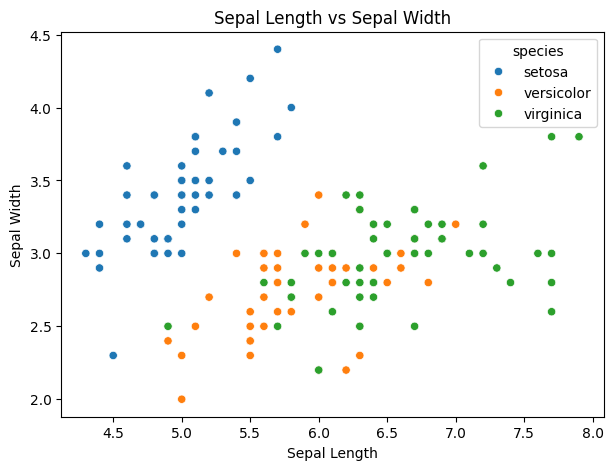

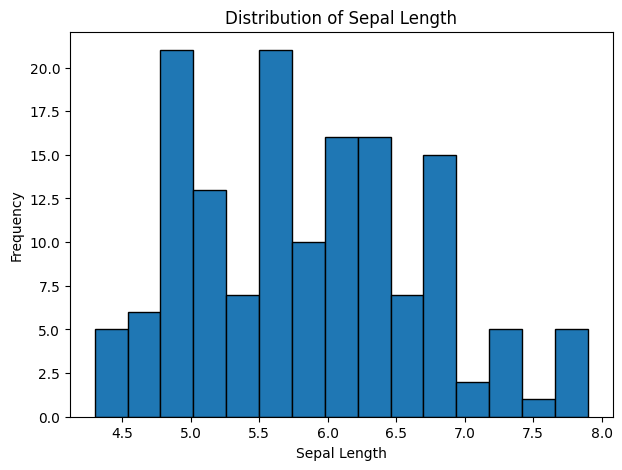

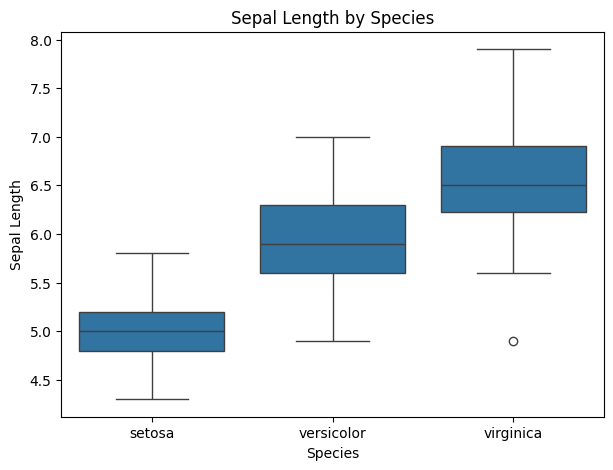

In [8]:
# 2. Data Visualization

# Scatter plot of Sepal Length vs Sepal Width
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species"
)
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()


# Histogram of Sepal Length
plt.figure(figsize=(7, 5))
plt.hist(df["sepal_length"], bins=15, edgecolor="black")
plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()


# Box plot of Sepal Length by Species
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="species",
    y="sepal_length"
)
plt.title("Sepal Length by Species")
plt.xlabel("Species")
plt.ylabel("Sepal Length")
plt.show()


3. Apply Gaussian Naïve Bayes to predict Species using the numerical features,
with an 80:20 train-test split.

In [9]:
# 3. Gaussian Naïve Bayes Classification

# Select numerical features
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

# Target variable
y = df["species"]


# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Create Gaussian Naïve Bayes model
model = GaussianNB()


# Train the model
model.fit(X_train, y_train)


# Predict species
y_pred = model.predict(X_test)



4. Display the classification report and accuracy

In [10]:
# 4. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Accuracy: 0.9666666666666667
Accuracy Percentage: 96.66666666666667 %
